In [1]:
import sys
import gc

sys.path.append("../..")  # Adds higher directory to python modules path.

from src import IOFunctions
from src import CalibrationFunctions

IO = IOFunctions.IO_Functions()

from src import MaskFunctions

Mask = MaskFunctions.Mask_Functions()

from src import PlottingBase
import pandas as pd

import os
import matplotlib.pyplot as plt
import numpy as np

plotter = PlottingBase.PublicationPlotter()

from src import HelperFunctions

H_F = HelperFunctions.Helper_Functions()

from scipy.stats import median_abs_deviation
from scipy.interpolate import interp1d

In [2]:
directories_hole = ['/media/jbeckwith/JSB_BACKUP_01/powermeter_calibration_data_throughhole_20260415/', '/media/jbeckwith/JSB_BACKUP_01/powermeter_calibration_data_throughhole_20260416/']

In [3]:
directories_filter = ['/media/jbeckwith/JSB_BACKUP_01/powermeter_calibration_data_throughfilters_20260415/',
                          '/media/jbeckwith/JSB_BACKUP_01/powermeter_calibration_data_throughfilters_20260416_5nm/']

In [4]:
wavelength_hole = {}
power_meter_hole = {}
wavelength_filter = {}
power_meter_filter = {}

In [5]:
for i, directory in enumerate(directories_hole):
    signal_files = H_F.file_search(directory, 'signal.csv', '')
    background_files = H_F.file_search(directory, 'background.csv', '')
    wavelength_spacing = int(500/(len(signal_files)-1))
    wavelength_hole[i] = np.arange(400, 900+wavelength_spacing, wavelength_spacing)
    power_meter_hole[i] = np.zeros([2, len(signal_files)])
    for j in np.arange(len(signal_files)):
        signal = np.median(pd.read_csv(signal_files[j]).power_W)
        signal_err = median_abs_deviation(pd.read_csv(signal_files[j]).power_W)
        background = np.median(pd.read_csv(background_files[j]).power_W)
        background_err = median_abs_deviation(pd.read_csv(background_files[j]).power_W)
        power_meter_hole[i][0, j] = signal - background
        power_meter_hole[i][1, j] = np.sqrt(np.square(signal_err) + np.square(background_err))

In [6]:
for i, directory in enumerate(directories_filter):
    signal_files = H_F.file_search(directory, 'signal.csv', '')
    background_files = H_F.file_search(directory, 'background.csv', '')
    wavelength_spacing = int(500/(len(signal_files)-1))
    wavelength_filter[i] = np.arange(400, 900+wavelength_spacing, wavelength_spacing)
    power_meter_filter[i] = np.zeros([2, len(signal_files)])
    for j in np.arange(len(signal_files)):
        signal = np.median(pd.read_csv(signal_files[j]).power_W)
        signal_err = median_abs_deviation(pd.read_csv(signal_files[j]).power_W)
        background = np.median(pd.read_csv(background_files[j]).power_W)
        background_err = median_abs_deviation(pd.read_csv(background_files[j]).power_W)
        power_meter_filter[i][0, j] = signal - background
        power_meter_filter[i][1, j] = np.sqrt(np.square(signal_err) + np.square(background_err))

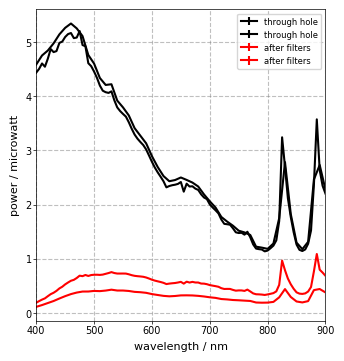

In [41]:
fig, axs = plotter.one_column_plot()

for i in np.arange(len(directories_hole)):
    axs.errorbar(wavelength_hole[i], power_meter_hole[i][0, :]*1e6, yerr=power_meter_hole[i][1, :], color='k', label='through hole')

for i in np.arange(len(directories_filter)):
    axs.errorbar(wavelength_filter[i], power_meter_filter[i][0, :]*1e6, yerr=power_meter_filter[i][1, :], color='red', label='after filters')


axs.set_ylabel('power / microwatt')
axs.set_xlabel('wavelength / nm')
axs.grid(True, ls='--', alpha=0.5, color='gray')
axs.set_xlim([400, 900])
axs.legend(loc='best')

folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Subgroup/20260427/'
plt.savefig(os.path.join(folder, 'Power_DifferentDays.svg'), dpi=600, format='svg')

In [10]:
power_calibration = power_meter_filter[0][0,:]/power_meter_hole[0][0,:]

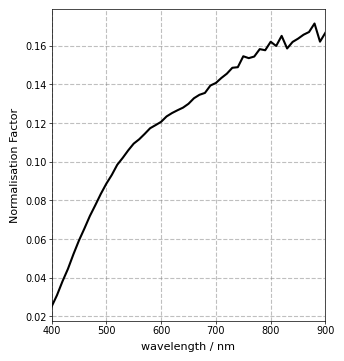

In [42]:
fig, axs = plotter.one_column_plot()

axs.plot(wavelength_filter[0], power_calibration, 'k')

axs.set_ylabel('Normalisation Factor')
axs.set_xlabel('wavelength / nm')
axs.grid(True, ls='--', alpha=0.5, color='gray')
axs.set_xlim([400, 900])
folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Subgroup/20260427/'
plt.savefig(os.path.join(folder, 'Normalisation_Factor.svg'), dpi=600, format='svg')

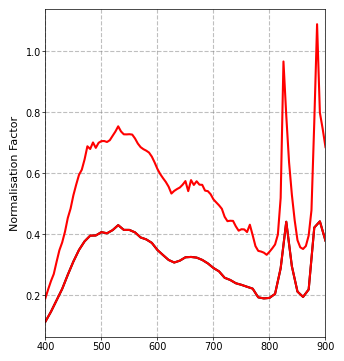

In [40]:
fig, axs = plotter.one_column_plot()

axs.plot(wavelength_filter[0], 1e6*power_meter_hole[0][0,:]*power_calibration, 'k')

for i in np.arange(len(directories_hole)):
    axs.errorbar(wavelength_hole[i], power_meter_filter[i][0, :]*1e6, yerr=power_meter_filter[i][1, :], color='red', label='through hole')

axs.set_ylabel('Normalisation Factor')
axs.grid(True, ls='--', alpha=0.5, color='gray')
axs.set_xlim([400, 900])
folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Subgroup/20260427/'
plt.savefig(os.path.join(folder, 'Test_Recapitulation.svg'), dpi=600, format='svg')

## Per-pixel QE calibration

Use the 100-frame monochromatic stacks (400–900 nm, 10 nm steps) and the power-meter readings to compute a per-pixel relative QE map at each wavelength.

**Method:**
1. Load camera calibration (offset, gain, variance) — *do not apply rqe flat-field*
2. For each wavelength: sigma-clip outlier frames using the calibrated noise model, then estimate μ_e per pixel via the constrained MLE (quadratic combining sample mean + variance with known σ_r²)
3. Normalise by the power-meter photon flux Φ(λ) = P(λ)·λ/(h·c) to remove source spectral variation
4. Divide by global maximum → relative QE ∈ [0, 1] per pixel per wavelength
5. Save as `Camera_Calibrations/ZWO_Camera/QE_per_pixel.tif` (51 frames × 2160 × 3840)

In [13]:
calib_dir = "../../Camera_Calibrations/ZWO_Camera"
offset   = IO.read_tiff(os.path.join(calib_dir, "offset.tif"))    # (H, W) ADU
gain     = IO.read_tiff(os.path.join(calib_dir, "gain.tif"))      # ADU / e⁻
variance = IO.read_tiff(os.path.join(calib_dir, "variance.tif"))  # ADU² dark read-noise
# rqe deliberately NOT loaded: it would suppress the per-pixel QE variation we want to measure

mosaic_unit = np.array([["R", "G"], ["G", "B"]])
masks = Mask.get_masks(
    mosaic_unit=mosaic_unit, size_x=offset.shape[0], size_y=offset.shape[1]
)

print(f"offset  : {offset.shape}  mean={offset.mean():.2f} ADU")
print(f"gain    : {gain.shape}   mean={gain.mean():.4f} ADU/e⁻")
print(f"variance: {variance.shape}  mean={variance.mean():.4f} ADU²")
print(f"σ_r     : {(np.sqrt(variance)/gain).mean():.3f} e⁻  (mean read noise)")

offset  : (2160, 3840)  mean=242.58 ADU
gain    : (2160, 3840)   mean=3.6111 ADU/e⁻
variance: (2160, 3840)  mean=9.8906 ADU²
σ_r     : 0.814 e⁻  (mean read noise)


In [14]:
qe_data_dir = '/media/jbeckwith/JSB_BACKUP_01/calibration_data_500frames_20260415/'
wavelengths_nm = np.arange(400, 910, 10)

In [15]:
import glob as _glob

# ── Power-meter readings from the image directories ────────────────────────────
# Each wavelength subdirectory (e.g. 400.0nm/) should contain power-meter CSVs
# with a 'power_W' column, named so that a sorted glob gives them in
# chronological order, e.g.:
#   signal_before.csv / background_before.csv   (taken before the image stack)
#   signal_after.csv  / background_after.csv    (taken after  the image stack)
# Any consistent naming with the same count of signal and background files works.
# The net power from each reading is averaged; a drift warning is raised if the
# first and last readings differ by more than FLAG_THRESH (fractional).

FLAG_THRESH = 0.05   # 5 % fractional drift triggers a warning

power_meter_raw     = np.zeros(len(wavelengths_nm))
power_meter_raw_err = np.zeros(len(wavelengths_nm))
_drift_flags        = []

for _idx, _wl in enumerate(wavelengths_nm):
    _wl_dir   = os.path.join(qe_data_dir, f"{_wl:.1f}nm")
    _sig_files = sorted(_glob.glob(os.path.join(_wl_dir, "signal*.csv")))
    _bg_files  = sorted(_glob.glob(os.path.join(_wl_dir, "background*.csv")))

    if len(_sig_files) == 0:
        raise FileNotFoundError(
            f"No signal*.csv found in {_wl_dir}.\n"
            "Expected files such as signal_before.csv and signal_after.csv."
        )
    if len(_sig_files) != len(_bg_files):
        raise ValueError(
            f"{_wl:.1f} nm: {len(_sig_files)} signal file(s) but "
            f"{len(_bg_files)} background file(s) — counts must match."
        )

    # Net power (signal − background) and its uncertainty for each reading
    _net_power = np.zeros(len(_sig_files))
    _net_err   = np.zeros(len(_sig_files))
    for _r, (_sf, _bf) in enumerate(zip(_sig_files, _bg_files)):
        _s = pd.read_csv(_sf).power_W
        _b = pd.read_csv(_bf).power_W
        _net_power[_r] = np.median(_s) - np.median(_b)
        _net_err[_r]   = np.sqrt(median_abs_deviation(_s)**2 +
                                  median_abs_deviation(_b)**2)

    # Average across readings; combined uncertainty = sqrt(Σ σ²) / N
    power_meter_raw[_idx]     = _net_power.mean()
    power_meter_raw_err[_idx] = np.sqrt((_net_err**2).sum()) / len(_net_err)

    # Drift check between first and last reading
    if len(_net_power) >= 2:
        _mean_p = abs(power_meter_raw[_idx])
        _frac   = abs(_net_power[-1] - _net_power[0]) / max(_mean_p, 1e-30)
        if _frac > FLAG_THRESH:
            _drift_flags.append(
                f"  {_wl:.0f} nm : {_frac*100:.1f}% drift  "
                f"({_net_power[0]*1e9:.3f} nW → {_net_power[-1]*1e9:.3f} nW)"
            )

# Interpolate power_calibration onto the image wavelength grid in case the
# through-hole and image acquisitions used different step sizes.
_pc_interp = interp1d(wavelength_hole[0], power_calibration,
                       kind='linear', fill_value='extrapolate')
_pc_at_wl  = _pc_interp(wavelengths_nm)   # filter-transmission factor at each λ

# Corrected power at the sensor: hole-path reading × filter transmission
power_meter     = power_meter_raw     * _pc_at_wl
power_meter_err = power_meter_raw_err * np.abs(_pc_at_wl)

print("Power at sensor after filter correction:")
for _i in range(0, len(wavelengths_nm), 5):
    print(f"  {wavelengths_nm[_i]:.0f} nm : "
          f"{power_meter[_i]*1e6:7.3f} ± {power_meter_err[_i]*1e6:.3f} μW")

if _drift_flags:
    print(f"\n⚠  Drift warnings — {len(_drift_flags)} wavelength(s) exceeded "
          f"{FLAG_THRESH*100:.0f}% between first and last reading:")
    for _msg in _drift_flags:
        print(_msg)
else:
    n_readings = len(sorted(_glob.glob(
        os.path.join(qe_data_dir, f"{wavelengths_nm[0]:.1f}nm", "signal*.csv"))))
    print(f"\nNo drift warnings ({n_readings} reading(s) per wavelength, "
          f"all within {FLAG_THRESH*100:.0f}%).")

Power at sensor after filter correction:
  400 nm :   0.115 ± 0.000 μW
  450 nm :   0.315 ± 0.000 μW
  500 nm :   0.410 ± 0.000 μW
  550 nm :   0.420 ± 0.000 μW
  600 nm :   0.353 ± 0.000 μW
  650 nm :   0.330 ± 0.000 μW
  700 nm :   0.297 ± 0.000 μW
  750 nm :   0.241 ± 0.000 μW
  800 nm :   0.197 ± 0.000 μW
  850 nm :   0.217 ± 0.000 μW
  900 nm :   0.385 ± 0.000 μW

No drift warnings (2 reading(s) per wavelength, all within 5%).


In [16]:
import tempfile

CHUNK_SIZE = 10   # frames per chunk — reduce if RAM is still tight

# ── Memory-mapped intermediate arrays (live on disk, not in RAM) ──────────────
_mm_dir        = tempfile.mkdtemp(prefix="qe_mmap_")
mean_e         = np.memmap(os.path.join(_mm_dir, "mean_e.dat"),
                            dtype=np.float32, mode='w+',
                            shape=(len(wavelengths_nm), *offset.shape))
var_e_expected = np.memmap(os.path.join(_mm_dir, "var_e.dat"),
                            dtype=np.float32, mode='w+',
                            shape=(len(wavelengths_nm), *offset.shape))
pixel_mask     = np.memmap(os.path.join(_mm_dir, "pixel_mask.dat"),
                            dtype=bool, mode='w+',
                            shape=(len(wavelengths_nm), *offset.shape))
pixel_mask[:]  = True   # initialise: all pixels assumed good

SIGMA_CLIP  = 5.0
CHI2_THRESH = 5.0

# Per-pixel read-noise variance in photoelectron units (known from calibration)
sigma_r2 = (variance / gain**2).astype(np.float64)   # (H, W)

for idx, wl_nm in enumerate(wavelengths_nm):
    tiff_path = os.path.join(qe_data_dir, f"{wl_nm:.1f}nm", "frames.tif")
    n_total   = IO.get_n_frames(tiff_path)

    # ── Pass 1: unclipped mean (float64 accumulator) ───────────────────────────
    sum_x = np.zeros(offset.shape, dtype=np.float64)
    for _s in range(0, n_total, CHUNK_SIZE):
        _frames = list(range(_s, min(_s + CHUNK_SIZE, n_total)))
        _raw    = IO.read_tiff(tiff_path, frame=_frames, dtype="float32", memmap=False)
        if _raw.ndim == 2:
            _raw = _raw[np.newaxis]
        sum_x += ((_raw - offset[np.newaxis]) / gain[np.newaxis]).sum(axis=0)
        del _raw
    xbar_init   = (sum_x / n_total).astype(np.float32)
    sigma_frame = np.sqrt(np.clip(sigma_r2 + xbar_init, 1e-6, None)).astype(np.float32)
    del sum_x

    # ── Pass 2: sigma-clipped sums (float64 accumulators) ─────────────────────
    sum_xc          = np.zeros(offset.shape, dtype=np.float64)   # Σ x  (clipped)
    sum_xc2         = np.zeros(offset.shape, dtype=np.float64)   # Σ x² (clipped)
    n_good          = np.zeros(offset.shape, dtype=np.int32)
    n_clipped_total = 0

    for _s in range(0, n_total, CHUNK_SIZE):
        _frames = list(range(_s, min(_s + CHUNK_SIZE, n_total)))
        _raw    = IO.read_tiff(tiff_path, frame=_frames, dtype="float32", memmap=False)
        if _raw.ndim == 2:
            _raw = _raw[np.newaxis]
        _x    = (_raw - offset[np.newaxis]) / gain[np.newaxis]   # (C, H, W)
        _good = np.abs(_x - xbar_init[np.newaxis]) < SIGMA_CLIP * sigma_frame[np.newaxis]
        sum_xc          += (_x * _good).sum(axis=0).astype(np.float64)
        sum_xc2         += (_x**2 * _good).sum(axis=0).astype(np.float64)
        n_good          += _good.sum(axis=0).astype(np.int32)
        n_clipped_total += int((~_good).sum())
        del _raw, _x, _good

    n_good_f = np.maximum(n_good, 1).astype(np.float64)
    xbar     = np.where(n_good > 1, sum_xc / n_good_f, xbar_init).astype(np.float32)

    # Unbiased sample variance via sum-of-squares identity: (Σx² - (Σx)²/n) / (n-1)
    s2 = np.where(
        n_good > 2,
        (sum_xc2 - sum_xc**2 / n_good_f) / np.maximum(n_good - 1, 1),
        sigma_r2 + xbar
    ).astype(np.float32)
    del sum_xc, sum_xc2

    # ── Constrained MLE (quadratic): x_k ~ N(μ, σ_r² + μ) ────────────────────
    _a    = sigma_r2.astype(np.float64)
    _xb   = xbar.astype(np.float64)
    _s2d  = s2.astype(np.float64)
    _B    = 2*_a + 1 - 2*_xb
    _C    = -(2*_a*_xb + _s2d - _a)
    _disc = np.maximum(_B**2 - 8*_C, 0.0)
    mu_e_f = ((-_B + np.sqrt(_disc)) / 4).astype(np.float32)
    del _a, _xb, _s2d, _B, _C, _disc

    # ── Write results to memory-mapped arrays ──────────────────────────────────
    mean_e[idx]         = mu_e_f
    var_e_expected[idx] = ((sigma_r2 + np.maximum(mu_e_f, 0)) / n_good_f).astype(np.float32)

    _expected_var_frame = np.clip(sigma_r2 + xbar, 1e-6, None)
    pixel_mask[idx]     = (s2 / _expected_var_frame) < CHI2_THRESH

    n_bad      = int((~pixel_mask[idx]).sum())
    clip_pct   = 100.0 * n_clipped_total / (n_total * offset.shape[0] * offset.shape[1])
    print(f"  {wl_nm:.0f} nm  G mean = {mu_e_f[masks['G']].mean():.1f} e⁻  "
          f"bad px = {n_bad}  clipped = {clip_pct:.4f}%      ", end="\r")

    del xbar_init, sigma_frame, xbar, s2, mu_e_f, n_good, n_good_f, _expected_var_frame
    mean_e.flush()
    var_e_expected.flush()
    pixel_mask.flush()
    gc.collect()

print("\nDone.")

  900 nm  G mean = 333.2 e⁻  bad px = 0  clipped = 0.0001%      
Done.


In [17]:
import tifffile as _tifffile

h_planck      = 6.626e-34   # J·s
c_light       = 2.998e8     # m/s
wavelengths_m = wavelengths_nm * 1e-9
Phi = power_meter * wavelengths_m / (h_planck * c_light)   # (N,) photons/s ∝ flux

save_dir     = "/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Salix/ZWO_Calibration"
qe_save_path = os.path.join(save_dir, "QE_per_pixel.tif")
wl_save_path = os.path.join(save_dir, "QE_per_pixel_wavelengths_nm.npy")

# ── Pass 1: find global R_max without loading the full (N, H, W) array ────────
R_max = 0.0
for _idx in range(len(wavelengths_nm)):
    _mu   = np.array(mean_e[_idx], dtype=np.float64)   # copy one slice from memmap
    _good = pixel_mask[_idx]
    _R_wl = np.where(_good, _mu, np.nan) / Phi[_idx]
    _wl_max = float(np.nanmax(_R_wl))
    if _wl_max > R_max:
        R_max = _wl_max
    del _mu, _R_wl
    gc.collect()

print(f"R_max = {R_max:.4e}")

# ── Pass 2: write QE_rel wavelength-by-wavelength and keep memmap for plots ───
QE_rel = np.memmap(os.path.join(_mm_dir, "QE_rel.dat"),
                   dtype=np.float32, mode='w+',
                   shape=(len(wavelengths_nm), *offset.shape))

with _tifffile.TiffWriter(qe_save_path, bigtiff=True) as _tif_out:
    for _idx in range(len(wavelengths_nm)):
        _mu    = np.array(mean_e[_idx], dtype=np.float64)
        _good  = pixel_mask[_idx]
        _QE_wl = (np.where(_good, _mu, np.nan) / Phi[_idx] / R_max).astype(np.float32)
        QE_rel[_idx] = _QE_wl
        _tif_out.write(_QE_wl, contiguous=True)
        del _mu, _QE_wl
        gc.collect()

QE_rel.flush()
np.save(wl_save_path, wavelengths_nm)

print(f"Saved  : {qe_save_path}")
print(f"  Shape: ({len(wavelengths_nm)}, {offset.shape[0]}, {offset.shape[1]})")
print(f"  R_max: {R_max:.4e}")
print(f"  λ range: {wavelengths_nm[0]}–{wavelengths_nm[-1]} nm  "
      f"(step {int(wavelengths_nm[1]-wavelengths_nm[0])} nm)")
print(f"  NaN pixels (bad): {int(np.isnan(QE_rel).sum())} / {QE_rel.size}")

R_max = 2.6315e-09
Saved  : /home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Salix/ZWO_Calibration/QE_per_pixel.tif
  Shape: (51, 2160, 3840)
  R_max: 2.6315e-09
  λ range: 400–900 nm  (step 10 nm)
  NaN pixels (bad): 3 / 423014400


In [113]:
# Spectral QE curves from SF (shape of curves), normalised so peak = 0.91 (ZWO sensor peak QE)
import src.SpectralFunctions as SpectralFunctions
SF    = SpectralFunctions.Spectral_Funcs()

R, G, B, wavelength = SF.getpixelefficiency(filename='/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Code/Python/pyBayerSMLM/Spectra/Camera_QE/ASI585MC_QE.csv')
Rx, Gx, Bx, wavelengthx = SF.getpixelefficiency()


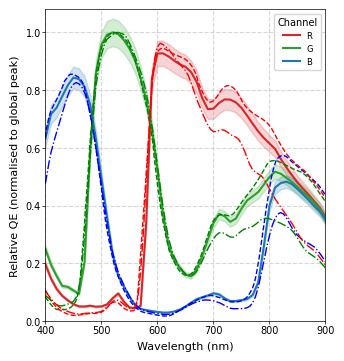

In [114]:
channel_colours = {"R": "tab:red", "G": "tab:green", "B": "tab:blue"}

qe_mean = {}
qe_std  = {}
qe_unc  = {}

rel_pm = power_meter_err / np.where(power_meter > 0, power_meter, np.nan)  # (51,)

for ch in channel_colours:
    m = masks[ch]  # (H, W) boolean

    means = np.zeros(len(wavelengths_nm))
    stds  = np.zeros(len(wavelengths_nm))
    uncs  = np.zeros(len(wavelengths_nm))

    for idx in range(len(wavelengths_nm)):
        good = m & pixel_mask[idx]                     # good pixels in this channel

        vals = QE_rel[idx][good].astype(np.float64)
        w    = 1.0 / np.clip(var_e_expected[idx][good].astype(np.float64), 1e-30, None)

        w_sum      = w.sum()
        mu_w       = (w * vals).sum() / w_sum
        means[idx] = mu_w
        stds[idx]  = np.sqrt((w * (vals - mu_w)**2).sum() / w_sum)  # weighted spatial std

        # Uncertainty of the weighted mean (measurement precision)
        meas_unc   = np.sqrt(1.0 / w_sum) / R_max
        uncs[idx]  = np.sqrt(meas_unc**2 + (mu_w * rel_pm[idx])**2)

    qe_mean[ch] = means
    qe_std[ch]  = stds
    qe_unc[ch]  = uncs

qe_max = np.max([qe_mean[ch] for ch in qe_mean.keys()])
fig, ax = plotter.one_column_plot()

for ch, colour in channel_colours.items():
    ax.plot(wavelengths_nm, qe_mean[ch]/qe_max, color=colour, lw=1.5, label=ch)
    ax.fill_between(
        wavelengths_nm,
        qe_mean[ch]/qe_max - qe_std[ch]/qe_max,
        qe_mean[ch]/qe_max + qe_std[ch]/qe_max,
        color=colour, alpha=0.2
    )
ax.plot(wavelength, B/np.max(G), color='blue', lw=1, ls='--')
ax.plot(wavelength, G/np.max(G), color='green', lw=1, ls='--')
ax.plot(wavelength, R/np.max(G), color='red', lw=1, ls='--')

ax.plot(wavelengthx, Bx/np.max(Gx), color='blue', lw=1, ls='-.')
ax.plot(wavelengthx, Gx/np.max(Gx), color='green', lw=1, ls='-.')
ax.plot(wavelengthx, Rx/np.max(Gx), color='red', lw=1, ls='-.')

ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Relative QE (normalised to global peak)")
ax.set_ylim(0, 1.08)
ax.set_xlim(400, 900)
ax.legend(title="Channel")
ax.grid(True, ls='--', alpha=0.5)
folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Subgroup/20260427/'
plt.savefig(os.path.join(folder, 'RGB_vs_Manufacturer_ZWO_andXimea.svg'), dpi=600, format='svg')

/tmp/ipykernel_15151/4076581844.py:15: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


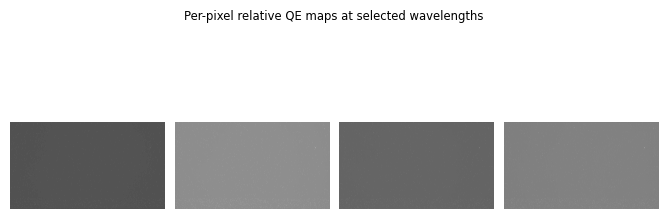

In [22]:
select_wl_nm = [450, 530, 620, 700]

fig, axs = plotter.two_column_plot(ncols=len(select_wl_nm))
for ax, wl in zip(axs, select_wl_nm):
    idx = int(np.where(wavelengths_nm == wl)[0][0])
    qe_map = QE_rel[idx].copy()
    vmax = float(np.nanpercentile(qe_map, 99.5))
    ax = plotter.image_plot(
        ax, qe_map,
        scalebarlabel="", scalebarsize=0, colorbar=False,
        vmin=0, vmax=vmax
    )

fig.suptitle("Per-pixel relative QE maps at selected wavelengths")
plt.tight_layout()
plt.show()

In [43]:
# ── Diagnostic: median χ² per wavelength ──────────────────────────────────────
# Re-uses stored mean_e memmap as the reference mean. Reads _N_chi2 evenly-spaced
# frames per wavelength and subsamples spatially (stride _stride) to keep I/O
# manageable (~130 k pixels, 20 frames per wavelength).

_stride = 8     # spatial stride
_N_chi2 = 20    # frames to sample per wavelength

_sr2_s = sigma_r2[::_stride, ::_stride]
_off_s = offset  [::_stride, ::_stride].astype(np.float64)
_gn_s  = gain    [::_stride, ::_stride].astype(np.float64)

chi2_median_wl = np.zeros(len(wavelengths_nm))
chi2_mad_wl    = np.zeros(len(wavelengths_nm))

for _idx, _wl in enumerate(wavelengths_nm):
    _tiff = os.path.join(qe_data_dir, f"{_wl:.1f}nm", "frames.tif")
    _ntot = IO.get_n_frames(_tiff)
    _sel  = np.linspace(0, _ntot - 1, _N_chi2, dtype=int).tolist()

    _mu  = mean_e[_idx].astype(np.float64)[::_stride, ::_stride]
    _sum = np.zeros_like(_mu)
    _ssq = np.zeros_like(_mu)

    for _c0 in range(0, len(_sel), CHUNK_SIZE):
        _fr  = _sel[_c0 : _c0 + CHUNK_SIZE]
        _raw = IO.read_tiff(_tiff, frame=_fr, dtype="float32", memmap=False)
        if _raw.ndim == 2:
            _raw = _raw[np.newaxis]
        _x   = (_raw[:, ::_stride, ::_stride].astype(np.float64) - _off_s) / _gn_s
        _sum += _x.sum(axis=0)
        _ssq += (_x ** 2).sum(axis=0)
        del _raw, _x

    _xbar = _sum / _N_chi2
    _s2   = (_ssq - _sum ** 2 / _N_chi2) / (_N_chi2 - 1)
    _ev   = np.clip(_sr2_s + np.maximum(_xbar, 0), 1e-6, None)
    _chi2 = (_s2 / _ev).ravel()

    chi2_median_wl[_idx] = np.median(_chi2)
    chi2_mad_wl[_idx]    = median_abs_deviation(_chi2)
    print(f"  {_wl:.0f} nm  median χ² = {chi2_median_wl[_idx]:.3f}", end="\r")

print("\nDone.")

  900 nm  median χ² = 0.942
Done.


/tmp/ipykernel_21595/279596994.py:10: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


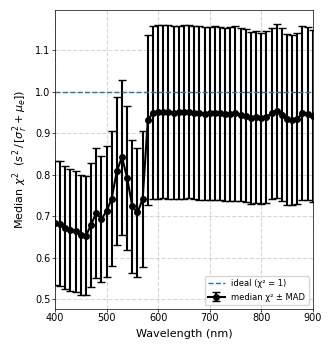

In [45]:
fig, ax = plotter.one_column_plot()
ax.errorbar(wavelengths_nm, chi2_median_wl, yerr=chi2_mad_wl,
            fmt='o-', color='k', ms=4, lw=1.5, capsize=3, label='median χ² ± MAD')
ax.axhline(1.0, color='tab:blue', ls='--', lw=1, label='ideal (χ² = 1)')
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel(r"Median $\chi^2$  ($s^2\,/\,[\sigma_r^2 + \mu_e]$)")
ax.set_xlim(400, 900)
ax.grid(True, ls='--', alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

In [115]:
# ── Mean spectrum per channel and per-pixel Euclidean spectral distance ────────
# Distance is computed relative to each pixel's own channel mean so the Bayer
# pattern does not dominate the map — only true spectral outliers stand out.

mean_spectrum_ch = {}
for ch in channel_colours:
    _m = masks[ch]
    mean_spectrum_ch[ch] = np.array([
        np.nanmean(QE_rel[_idx][_m]) for _idx in range(len(wavelengths_nm))
    ])

dist_map = np.full(offset.shape, np.nan, dtype=np.float32)

for ch in channel_colours:
    _m       = masks[ch]
    _dist_sq = np.zeros(offset.shape, dtype=np.float64)
    _n_valid = np.zeros(offset.shape, dtype=np.int32)

    for _idx in range(len(wavelengths_nm)):
        _qe  = QE_rel[_idx].astype(np.float64)
        _fin = np.isfinite(_qe)
        _dist_sq += np.where(_fin & _m, (_qe - mean_spectrum_ch[ch][_idx]) ** 2, 0.0)
        _n_valid += (_fin & _m).astype(np.int32)
        del _qe, _fin

    _valid = (_n_valid == len(wavelengths_nm)) & _m
    dist_map[_valid] = np.sqrt(_dist_sq[_valid]).astype(np.float32)
    del _dist_sq, _n_valid

print("Distance map summary:")
for ch in channel_colours:
    _v = dist_map[masks[ch]]
    _v = _v[np.isfinite(_v)]
    print(f"  {ch}: median = {np.median(_v):.4f},  99th pct = {np.percentile(_v, 99):.4f}")

Distance map summary:
  R: median = 0.0067,  99th pct = 0.0214
  G: median = 0.0074,  99th pct = 0.0207
  B: median = 0.0056,  99th pct = 0.0174


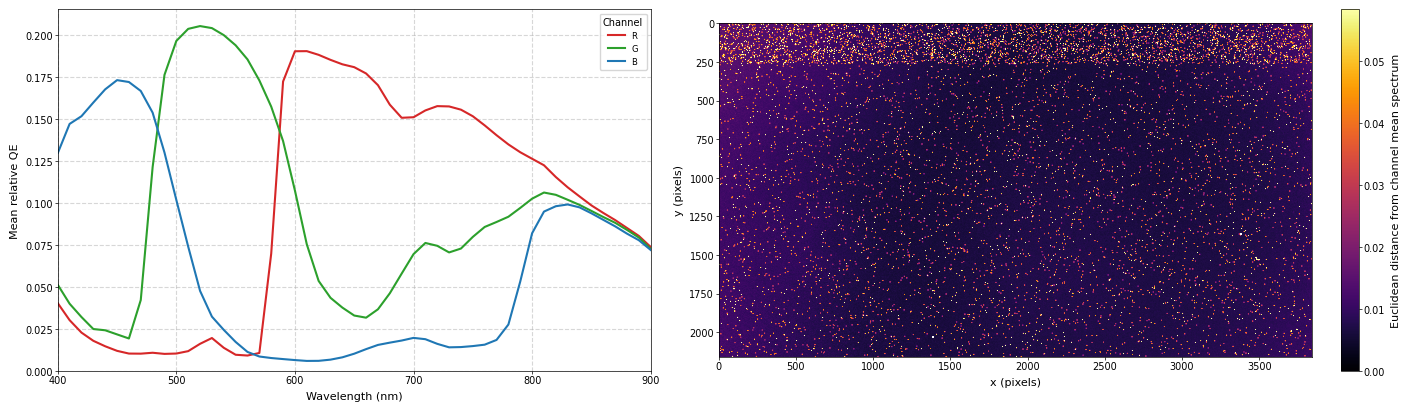

In [116]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4))

# Left: per-channel mean spectra
ax = axs[0]
for ch, colour in channel_colours.items():
    ax.plot(wavelengths_nm, mean_spectrum_ch[ch], color=colour, lw=1.5, label=ch)
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Mean relative QE")
ax.set_xlim(400, 900)
ax.set_ylim(0)
ax.grid(True, ls='--', alpha=0.5)
ax.legend(title="Channel")

# Right: distance map — clipped at 99.5th percentile to suppress extreme outliers
ax = axs[1]
vmax = float(np.nanpercentile(dist_map, 99.9))
im = ax.imshow(dist_map, vmin=0, vmax=vmax, cmap='inferno', origin='upper')
plt.colorbar(im, ax=ax, label='Euclidean distance from channel mean spectrum')
ax.set_xlabel("x (pixels)")
ax.set_ylabel("y (pixels)")

#plt.tight_layout()
plt.show()

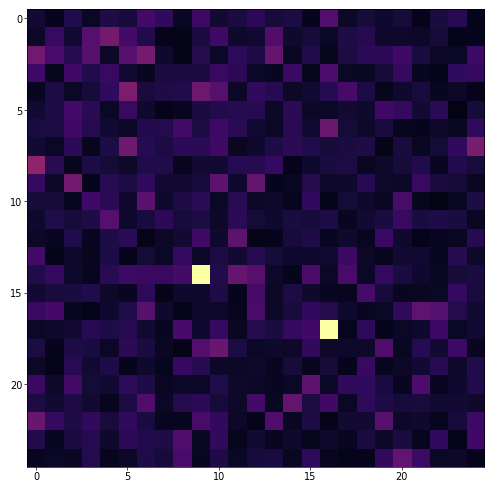

In [118]:
# ── Per-wavelength 2D polynomial illumination fit ─────────────────────────────
# Block-averages QE_rel on a BLOCK×BLOCK grid (mixing all Bayer channels —
# valid since the R:G:B ratio is identical in every block), fits a degree-
# POLY_DEG 2D polynomial to capture the smooth illumination envelope, then
# assesses how consistent the spatial pattern is across wavelengths.

BLOCK    = 32
POLY_DEG = 2

H, W = offset.shape
_ny, _nx = H // BLOCK, W // BLOCK

# Normalised block-centre coordinates ([-1,1] for numerical stability)
_BX, _BY = np.meshgrid(
    (np.arange(_nx) + 0.5) * BLOCK,
    (np.arange(_ny) + 0.5) * BLOCK,
)
_xn_b = (_BX.ravel() - W / 2) / (W / 2)
_yn_b = (_BY.ravel() - H / 2) / (H / 2)

# Full-resolution normalised coordinates
_XF, _YF = np.meshgrid(
    (np.arange(W) - W / 2) / (W / 2),
    (np.arange(H) - H / 2) / (H / 2),
)

def _poly2d_vander(xv, yv, deg):
    cols = [np.ones(len(xv))]
    for d in range(1, deg + 1):
        for i in range(d + 1):
            cols.append(xv ** (d - i) * yv ** i)
    return np.column_stack(cols)

_Vc = _poly2d_vander(_xn_b,        _yn_b,        POLY_DEG)   # (ny*nx, n_terms)
_Vf = _poly2d_vander(_XF.ravel(),  _YF.ravel(),  POLY_DEG)   # (H*W,   n_terms)

illum_fit = np.zeros((len(wavelengths_nm), H, W), dtype=np.float32)
fit_rms   = np.zeros(len(wavelengths_nm))

for _idx, _wl in enumerate(wavelengths_nm):
    _qe  = QE_rel[_idx].astype(np.float64)
    _fin = np.isfinite(_qe)

    # Vectorised block average over all finite pixels
    _safe = np.where(_fin, _qe, 0.0)
    _qe_b = _safe[:_ny*BLOCK, :_nx*BLOCK].reshape(_ny, BLOCK, _nx, BLOCK)
    _fin_b = _fin[:_ny*BLOCK, :_nx*BLOCK].reshape(_ny, BLOCK, _nx, BLOCK)
    _cnt  = _fin_b.sum(axis=(1, 3)).astype(float)
    _bavg = np.where(_cnt > 0, _qe_b.sum(axis=(1, 3)) / np.maximum(_cnt, 1), np.nan)

    # Least-squares polynomial fit to finite blocks
    _ok      = np.isfinite(_bavg.ravel())
    _coeffs, _, _, _ = np.linalg.lstsq(_Vc[_ok], _bavg.ravel()[_ok], rcond=None)

    # Fractional RMS residual
    _pred    = _Vc[_ok] @ _coeffs
    fit_rms[_idx] = (np.sqrt(np.mean((_bavg.ravel()[_ok] - _pred) ** 2))
                     / _bavg.ravel()[_ok].mean())

    # Full-resolution illumination map, normalised so mean = 1
    _fit = (_Vf @ _coeffs).reshape(H, W)
    _fit /= _fit.mean()
    illum_fit[_idx] = _fit.astype(np.float32)
    del _qe, _fin, _safe, _qe_b, _fin_b, _bavg, _fit

# Pairwise Pearson correlation between illumination maps
_f = illum_fit.reshape(len(wavelengths_nm), -1).astype(np.float64)
_f -= _f.mean(axis=1, keepdims=True)
_f /= np.linalg.norm(_f, axis=1, keepdims=True)
illum_corr = _f @ _f.T
del _f

_od = illum_corr[np.triu_indices(len(wavelengths_nm), k=1)]
print(f"Block-fit fractional RMS:  mean={fit_rms.mean():.4f}  max={fit_rms.max():.4f}")
print(f"Inter-wavelength illumination correlation:")
print(f"  min={_od.min():.3f}  median={np.median(_od):.3f}  max={_od.max():.3f}")

Block-fit fractional RMS:  mean=0.0042  max=0.0054
Inter-wavelength illumination correlation:
  min=-0.215  median=0.764  max=1.000


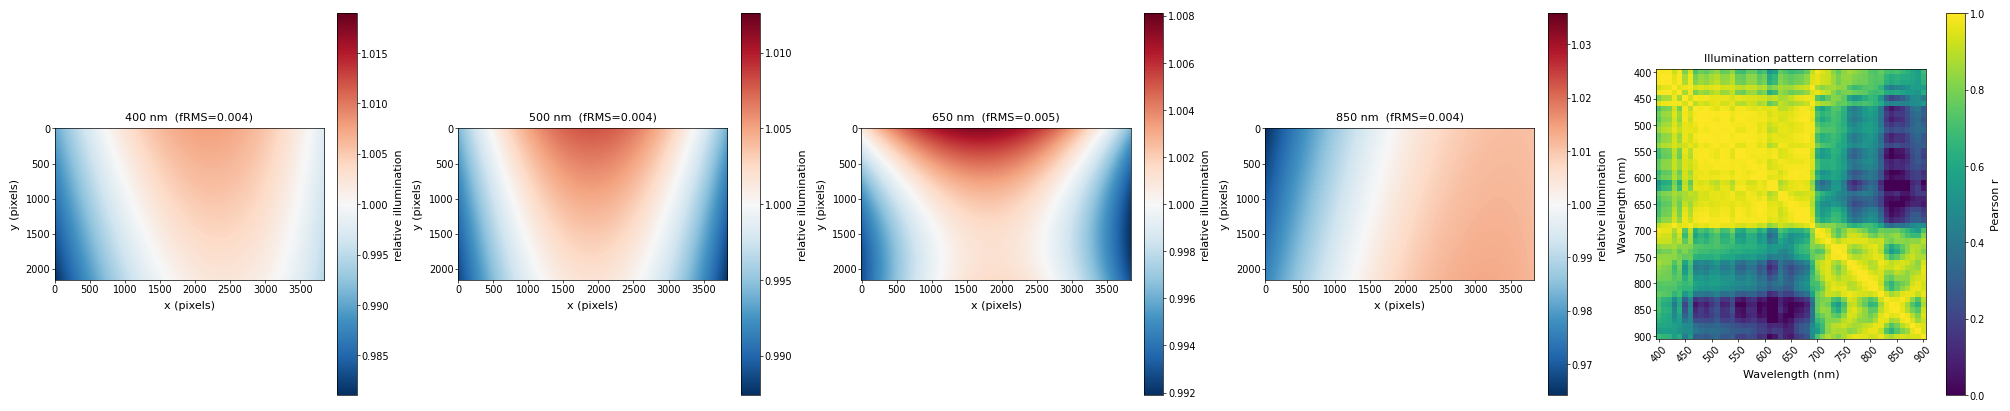

In [120]:
_sel_wl = [400, 500, 650, 850]
fig, axs = plt.subplots(1, len(_sel_wl) + 1, figsize=(4 * (len(_sel_wl) + 1), 4))

for ax, _wl in zip(axs[:-1], _sel_wl):
    _idx = int(np.where(wavelengths_nm == _wl)[0][0])
    _map = illum_fit[_idx]
    _dev = max(abs(float(_map.max()) - 1), abs(float(_map.min()) - 1))
    im = ax.imshow(_map, vmin=1 - _dev, vmax=1 + _dev, cmap='RdBu_r', origin='upper')
    plt.colorbar(im, ax=ax, label='relative illumination')
    ax.set_title(f"{_wl} nm  (fRMS={fit_rms[_idx]:.3f})")
    ax.set_xlabel("x (pixels)")
    ax.set_ylabel("y (pixels)")

ax = axs[-1]
im = ax.imshow(illum_corr, vmin=0, vmax=1, cmap='viridis', origin='upper')
plt.colorbar(im, ax=ax, label='Pearson r')
_ti = np.arange(0, len(wavelengths_nm), 5)
ax.set_xticks(_ti);  ax.set_xticklabels(wavelengths_nm[_ti], rotation=45, fontsize=7)
ax.set_yticks(_ti);  ax.set_yticklabels(wavelengths_nm[_ti], fontsize=7)
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Wavelength (nm)")
ax.set_title("Illumination pattern correlation")

plt.show()

In [121]:
# ── Apply per-wavelength illumination correction ──────────────────────────────
# illum_fit[λ] has mean=1, so dividing preserves the spatial-mean QE at each λ
# while flattening the beam profile.  Re-normalise to global max afterwards.

QE_corr_path = os.path.join(save_dir, "QE_per_pixel_illum_corrected.tif")
QE_corr = np.memmap(os.path.join(_mm_dir, "QE_corr.dat"),
                    dtype=np.float32, mode='w+',
                    shape=(len(wavelengths_nm), *offset.shape))

for _idx in range(len(wavelengths_nm)):
    _qe = QE_rel[_idx].astype(np.float64)
    _il = illum_fit[_idx].astype(np.float64)
    QE_corr[_idx] = np.where(np.isfinite(_qe), _qe / _il, np.nan).astype(np.float32)

_R_max_c = max(float(np.nanmax(QE_corr[_idx])) for _idx in range(len(wavelengths_nm)))
for _idx in range(len(wavelengths_nm)):
    QE_corr[_idx] = (QE_corr[_idx] / _R_max_c).astype(np.float32)
QE_corr.flush()

with _tifffile.TiffWriter(QE_corr_path, bigtiff=True) as _tif:
    for _idx in range(len(wavelengths_nm)):
        _tif.write(QE_corr[_idx], contiguous=True)
print(f"Saved: {QE_corr_path}")

# Recompute per-channel mean spectra and spectral distance on corrected QE
mean_spectrum_corr = {}
for ch in channel_colours:
    _m = masks[ch]
    mean_spectrum_corr[ch] = np.array([
        np.nanmean(QE_corr[_idx][_m]) for _idx in range(len(wavelengths_nm))
    ])

dist_map_corr = np.full(offset.shape, np.nan, dtype=np.float32)
for ch in channel_colours:
    _m   = masks[ch]
    _dsq = np.zeros(offset.shape, dtype=np.float64)
    _nv  = np.zeros(offset.shape, dtype=np.int32)
    for _idx in range(len(wavelengths_nm)):
        _qe  = QE_corr[_idx].astype(np.float64)
        _fin = np.isfinite(_qe)
        _dsq += np.where(_fin & _m, (_qe - mean_spectrum_corr[ch][_idx]) ** 2, 0.0)
        _nv  += (_fin & _m).astype(np.int32)
        del _qe, _fin
    _valid = (_nv == len(wavelengths_nm)) & _m
    dist_map_corr[_valid] = np.sqrt(_dsq[_valid]).astype(np.float32)
    del _dsq, _nv

print("\nSpectral distance after correction:")
for ch in channel_colours:
    _v = dist_map_corr[masks[ch]]
    _v = _v[np.isfinite(_v)]
    print(f"  {ch}: median={np.median(_v):.4f}  99th pct={np.percentile(_v, 99):.4f}")

Saved: /home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Salix/ZWO_Calibration/QE_per_pixel_illum_corrected.tif

Spectral distance after correction:
  R: median=0.0048  99th pct=0.0171
  G: median=0.0060  99th pct=0.0181
  B: median=0.0045  99th pct=0.0151


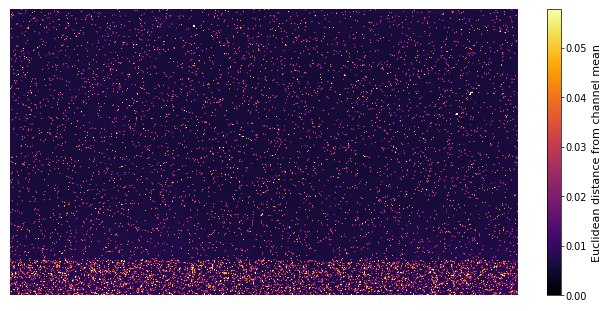

In [205]:
fig, axs = plotter.two_column_plot()


axs = plotter.image_plot(axs, image=dist_map_corr, vmin=0, vmax=np.nanpercentile(dist_map_corr, 99.9), cmap='inferno', colorbar=False)
plt.colorbar(im1, ax=axs[0], label='Euclidean distance from channel mean')


folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Subgroup/20260427/'
plt.savefig(os.path.join(folder, 'Euclidean_Distance_ZWO.svg'), dpi=600, format='svg')
plt.show()

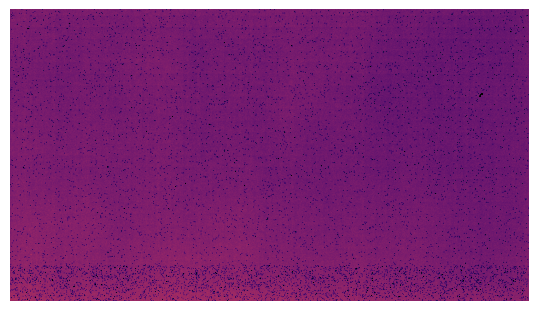

In [215]:
fig, axs = plotter.two_column_plot()


axs = plotter.image_plot(axs, image=gain, vmin=np.nanpercentile(gain, 1), vmax=np.nanpercentile(gain, 99.9), cmap='inferno', colorbar=False)


folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Subgroup/20260427/'
plt.savefig(os.path.join(folder, 'Gain_ZWO.svg'), dpi=600, format='svg')
plt.show()

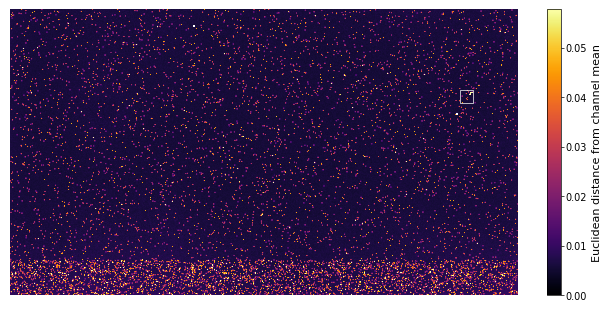

In [206]:
fig, axs = plotter.two_column_plot()


axs = plotter.image_plot(axs, image=dist_map_corr, vmin=0, vmax=np.nanpercentile(dist_map_corr, 99.9), cmap='inferno', colorbar=False)
plt.colorbar(im1, ax=axs[0], label='Euclidean distance from channel mean')

import matplotlib.patches as patches
oversampling = 1
xmin = 3400
ymin = 1450
rect = patches.Rectangle(
    (xmin * oversampling, ymin * oversampling),
    100 * oversampling,
    100 * oversampling,
    linewidth=0.5,
    edgecolor="white",
    facecolor="none",
)

# Add the patch to the Axes
axs[0].add_patch(rect)

folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Subgroup/20260427/'
plt.savefig(os.path.join(folder, 'Euclidean_Distance_ZWO_Zoom.svg'), dpi=600, format='svg')
plt.show()

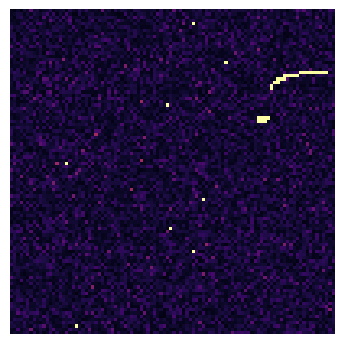

In [207]:
fig, axs = plotter.one_column_plot()


axs = plotter.image_plot(axs, dist_map_corr[ymin:ymin+100, xmin:xmin+100], vmin=0, vmax=np.nanpercentile(dist_map_corr, 99.9), cmap='inferno')

folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Subgroup/20260427/'
plt.savefig(os.path.join(folder, 'Euclidean_Distance_ZWO_ZoomArea.svg'), dpi=600, format='svg')
plt.show()

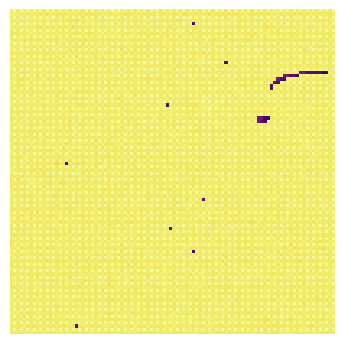

In [208]:
fig, axs = plotter.one_column_plot()


axs = plotter.image_plot(axs, gain[ymin:ymin+100, xmin:xmin+100], vmin=0, vmax=np.nanpercentile(gain, 99.9), cmap='inferno')

folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Subgroup/20260427/'
plt.savefig(os.path.join(folder, 'Gain_ZWO_ZoomArea.svg'), dpi=600, format='svg')
plt.show()

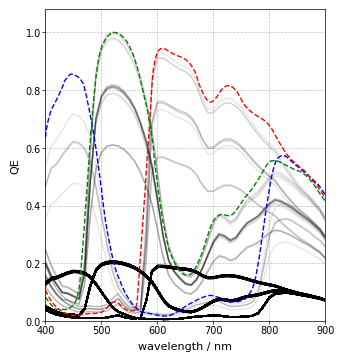

In [188]:
fig, ax = plotter.one_column_plot()

for i in np.arange(ymin, ymin+100):
    for j in np.arange(xmin, xmin+100):
        ax = plotter.line_plot(ax, wavelengths_nm, QE_corr[:, i, j], alpha=0.1)

ax.plot(wavelength, B/np.max(G), color='blue', lw=1, ls='--')
ax.plot(wavelength, G/np.max(G), color='green', lw=1, ls='--')
ax.plot(wavelength, R/np.max(G), color='red', lw=1, ls='--')

ax.set_ylim(0, 1.08)
ax.set_xlim(400, 900)
ax.grid(True, ls='--', alpha=0.5)
ax.set_xlabel('wavelength / nm')
ax.set_ylabel('QE')
folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Subgroup/20260427/'
plt.savefig(os.path.join(folder, 'RGB_vs_Manufacturer_ZWO_Zoom.svg'), dpi=600, format='svg')

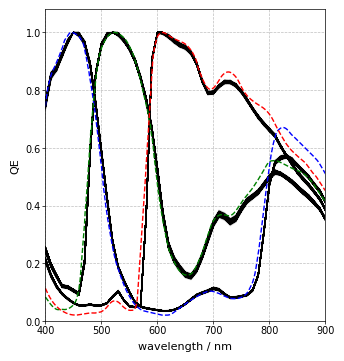

In [193]:
fig, ax = plotter.one_column_plot()

for i in np.arange(ymin, ymin+100):
    for j in np.arange(xmin, xmin+100):
        ax = plotter.line_plot(ax, wavelengths_nm, QE_corr[:, i, j]/np.max(QE_corr[:, i, j]), alpha=0.01)

ax.plot(wavelength, B/np.max(B), color='blue', lw=1, ls='--')
ax.plot(wavelength, G/np.max(G), color='green', lw=1, ls='--')
ax.plot(wavelength, R/np.max(R), color='red', lw=1, ls='--')

ax.set_ylim(0, 1.08)
ax.set_xlim(400, 900)
ax.grid(True, ls='--', alpha=0.5)
ax.set_xlabel('wavelength / nm')
ax.set_ylabel('QE')
folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Subgroup/20260427/'
plt.savefig(os.path.join(folder, 'RGB_vs_Manufacturer_ZWO_Zoom_Normalised.svg'), dpi=600, format='svg')